<a href="https://colab.research.google.com/github/Sreeja-Sriram01/AgeLock-A-Privacy_Preserving_Browser_with_On_Device_Age_Based_Content_Filtering/blob/main/EEG_Classification_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install snntorch torch numpy pandas scikit-learn matplotlib seaborn --quiet

In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate, spikegen
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [32]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Option A: Local file
#df = pd.read_csv('Epileptic_Seizure_Recognition.csv')

# Option B: Google Colab
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/Epileptic Seizure Recognition.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:5]} ... {df.columns.tolist()[-3:]}")
print(f"\nLabel distribution (original 5-class):")
print(df['y'].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (11500, 180)
Columns: ['Unnamed', 'X1', 'X2', 'X3', 'X4'] ... ['X177', 'X178', 'y']

Label distribution (original 5-class):
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64


Feature matrix shape: (11500, 178)
Seizure     (class 1): 2,300  (20.0%)
Non-seizure (class 0): 9,200 (80.0%)


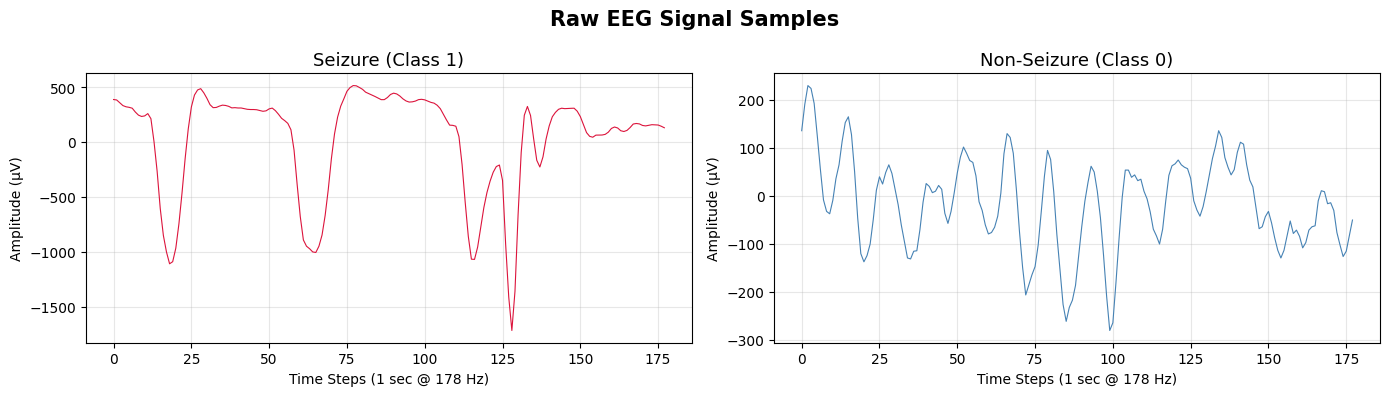

In [33]:
# Drop identifier column
if 'Unnamed' in df.columns:
    df = df.drop(columns=['Unnamed'])

# Binary label: 1 = seizure, 0 = non-seizure
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

X = df.drop(columns=['y']).values  # (11500, 178)
y = df['y'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Seizure     (class 1): {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"Non-seizure (class 0): {(1-y).sum():,} ({(1-y.mean())*100:.1f}%)")

# Visualise raw EEG samples
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
seizure_idx    = np.where(y == 1)[0][0]
nonseizure_idx = np.where(y == 0)[0][0]

for ax, idx, label, color in zip(
    axes,
    [seizure_idx, nonseizure_idx],
    ['Seizure (Class 1)', 'Non-Seizure (Class 0)'],
    ['crimson', 'steelblue']
):
    ax.plot(X[idx], color=color, linewidth=0.8)
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Time Steps (1 sec @ 178 Hz)')
    ax.set_ylabel('Amplitude (µV)')
    ax.grid(alpha=0.3)

plt.suptitle('Raw EEG Signal Samples', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# StandardScaler normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples")

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

Train: 9,200 samples  |  Test: 2,300 samples


Spike train shape (train): torch.Size([50, 9200, 178])
Spike train shape (test) : torch.Size([50, 2300, 178])


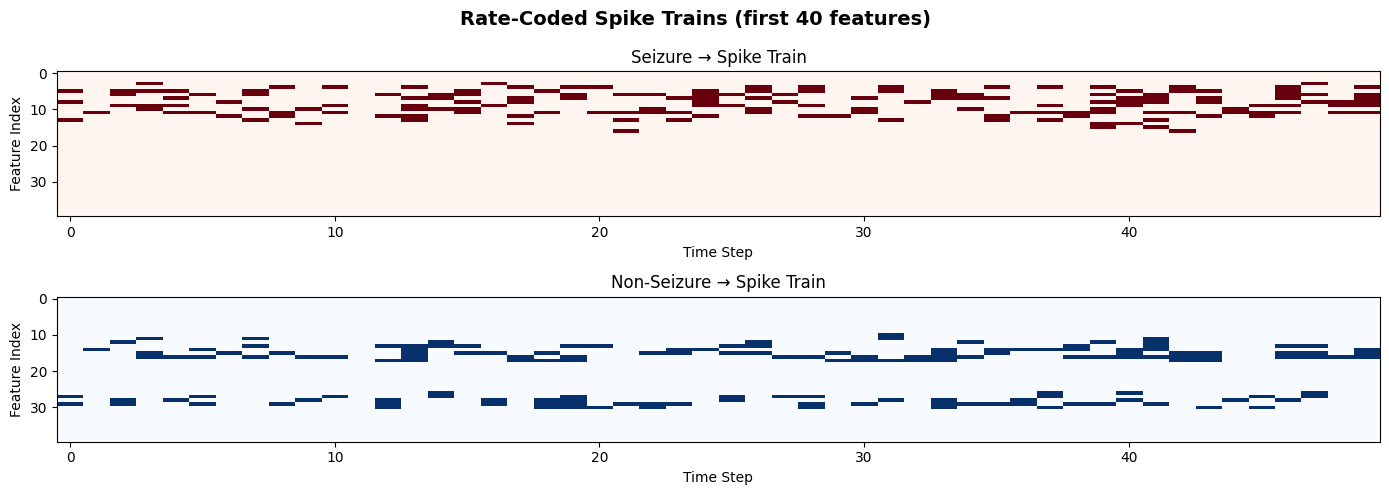

In [35]:
# Rate-based spike encoding
# Each normalised value is treated as a firing probability over num_steps
# Output shape: (num_steps, N_samples, N_features)
NUM_STEPS = 50

X_train_spikes = spikegen.rate(X_train_t, num_steps=NUM_STEPS)
X_test_spikes  = spikegen.rate(X_test_t,  num_steps=NUM_STEPS)

print(f"Spike train shape (train): {X_train_spikes.shape}")
print(f"Spike train shape (test) : {X_test_spikes.shape}")

# Visualise spike encoding
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

for ax, class_idx, label, cmap in zip(
    axes,
    [1, 0],
    ['Seizure → Spike Train', 'Non-Seizure → Spike Train'],
    ['Reds', 'Blues']
):
    sample_idx = (y_train == class_idx).nonzero()[0][0]
    spike_data = X_train_spikes[:, sample_idx, :40].numpy()
    ax.imshow(spike_data.T, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Feature Index')

plt.suptitle('Rate-Coded Spike Trains (first 40 features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
class MLMSNN(nn.Module):
    """
    Multi-Layer Multi-Spiking Neural Network.

    Architecture:
        Input (178) → FC1 → LIF1 → BN1
                    → FC2 → LIF2 → BN2
                    → FC3 → LIF3
                    → FC_out (2 classes, spike-rate readout)

    Key improvements over baseline:
      • Batch Normalisation after each spiking layer
      • Dropout regularisation
      • Proper membrane potential reset between batches
      • Spike-rate accumulation for stable readout
    """
    def __init__(self, input_size, hidden1=256, hidden2=128, hidden3=64,
                 num_classes=2, beta=0.9, dropout=0.3):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        # Layer 1
        self.fc1   = nn.Linear(input_size, hidden1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.bn1   = nn.BatchNorm1d(hidden1)
        self.drop1 = nn.Dropout(dropout)

        # Layer 2
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.bn2   = nn.BatchNorm1d(hidden2)
        self.drop2 = nn.Dropout(dropout)

        # Layer 3
        self.fc3   = nn.Linear(hidden2, hidden3)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.drop3 = nn.Dropout(dropout)

        # Output readout layer
        self.fc_out = nn.Linear(hidden3, num_classes)

    def forward(self, x_spike_seq):
        """
        x_spike_seq: (num_steps, batch, input_size)
        Returns logits: (batch, num_classes)
        """
        num_steps = x_spike_seq.shape[0]
        batch     = x_spike_seq.shape[1]

        # Initialise membrane potentials fresh each forward pass
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Accumulate spike-rate over time
        spk3_sum = torch.zeros(batch, self.fc3.out_features,
                               device=x_spike_seq.device)

        for t in range(num_steps):
            x_t = x_spike_seq[t]           # (batch, input_size)

            # Layer 1
            cur1       = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1       = self.drop1(self.bn1(spk1))

            # Layer 2
            cur2       = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2       = self.drop2(self.bn2(spk2))

            # Layer 3
            cur3       = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk3       = self.drop3(spk3)

            spk3_sum  += spk3

        # Spike-rate readout → logits
        logits = self.fc_out(spk3_sum / num_steps)
        return logits


# Instantiate
INPUT_SIZE = X_train.shape[1]  # 178
model = MLMSNN(input_size=INPUT_SIZE).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

MLMSNN(
  (fc1): Linear(in_features=178, out_features=256, bias=True)
  (lif1): Leaky()
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (lif2): Leaky()
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (lif3): Leaky()
  (drop3): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 87,874


In [37]:
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters
BATCH_SIZE    = 64
EPOCHS        = 30
LEARNING_RATE = 0.01
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4

# Class weights to handle imbalance (1 seizure : 4 non-seizure)
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(2)], dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Mini-Batch SGD with Nesterov momentum
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True
)

# Reduce LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# DataLoader — permute so DataLoader indexes along sample axis
train_dataset = TensorDataset(X_train_spikes.permute(1, 0, 2), y_train_t)
test_dataset  = TensorDataset(X_test_spikes.permute(1, 0, 2),  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 144 | Test batches: 36


In [38]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(EPOCHS):

    # ── Train ──
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for spk_batch, labels in train_loader:
        # DataLoader gives (batch, num_steps, features) → permute back
        spk_batch = spk_batch.permute(1, 0, 2).to(device)
        labels    = labels.to(device)

        optimizer.zero_grad()
        logits = model(spk_batch)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in SNNs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_loss /= total
    train_acc   = correct / total

    # ── Validation ──
    model.eval()
    val_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for spk_batch, labels in test_loader:
            spk_batch = spk_batch.permute(1, 0, 2).to(device)
            labels    = labels.to(device)
            logits    = model(spk_batch)
            loss      = criterion(logits, labels)

            val_loss  += loss.item() * labels.size(0)
            preds      = logits.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total   += labels.size(0)

    val_loss /= v_total
    val_acc   = v_correct / v_total

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'SNN_EEG_best.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")

Epoch [01/30] Train Loss: 0.3923  Acc: 83.59%  |  Val Loss: 0.3404  Acc: 81.22%
Epoch [05/30] Train Loss: 0.1975  Acc: 92.38%  |  Val Loss: 0.2055  Acc: 92.48%
Epoch [10/30] Train Loss: 0.1511  Acc: 94.43%  |  Val Loss: 0.2418  Acc: 90.83%
Epoch [15/30] Train Loss: 0.1203  Acc: 95.68%  |  Val Loss: 0.2455  Acc: 92.87%
Epoch [20/30] Train Loss: 0.1086  Acc: 96.03%  |  Val Loss: 0.2624  Acc: 92.87%
Epoch [25/30] Train Loss: 0.0982  Acc: 96.58%  |  Val Loss: 0.2808  Acc: 90.52%
Epoch [30/30] Train Loss: 0.0884  Acc: 96.79%  |  Val Loss: 0.2781  Acc: 93.87%

Best Validation Accuracy: 94.61%


In [39]:
# Load best checkpoint
model.load_state_dict(torch.load('SNN_EEG_best.pth', map_location=device))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for spk_batch, labels in test_loader:
        spk_batch = spk_batch.permute(1, 0, 2).to(device)
        logits    = model(spk_batch)
        probs     = torch.softmax(logits, dim=1)[:, 1]
        preds     = logits.argmax(dim=1)

        all_preds .extend(preds.cpu().numpy())
        all_probs .extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)

print("=" * 50)
print("         PERFORMANCE ANALYSIS")
print("=" * 50)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {auc*100:.2f}%")
print("=" * 50)
print()
print(classification_report(all_labels, all_preds,
                             target_names=['Non-Seizure', 'Seizure']))

         PERFORMANCE ANALYSIS
  Accuracy  : 94.61%
  Precision : 84.85%
  Recall    : 88.91%
  F1-Score  : 86.84%
  ROC-AUC   : 97.66%

              precision    recall  f1-score   support

 Non-Seizure       0.97      0.96      0.97      1840
     Seizure       0.85      0.89      0.87       460

    accuracy                           0.95      2300
   macro avg       0.91      0.92      0.92      2300
weighted avg       0.95      0.95      0.95      2300



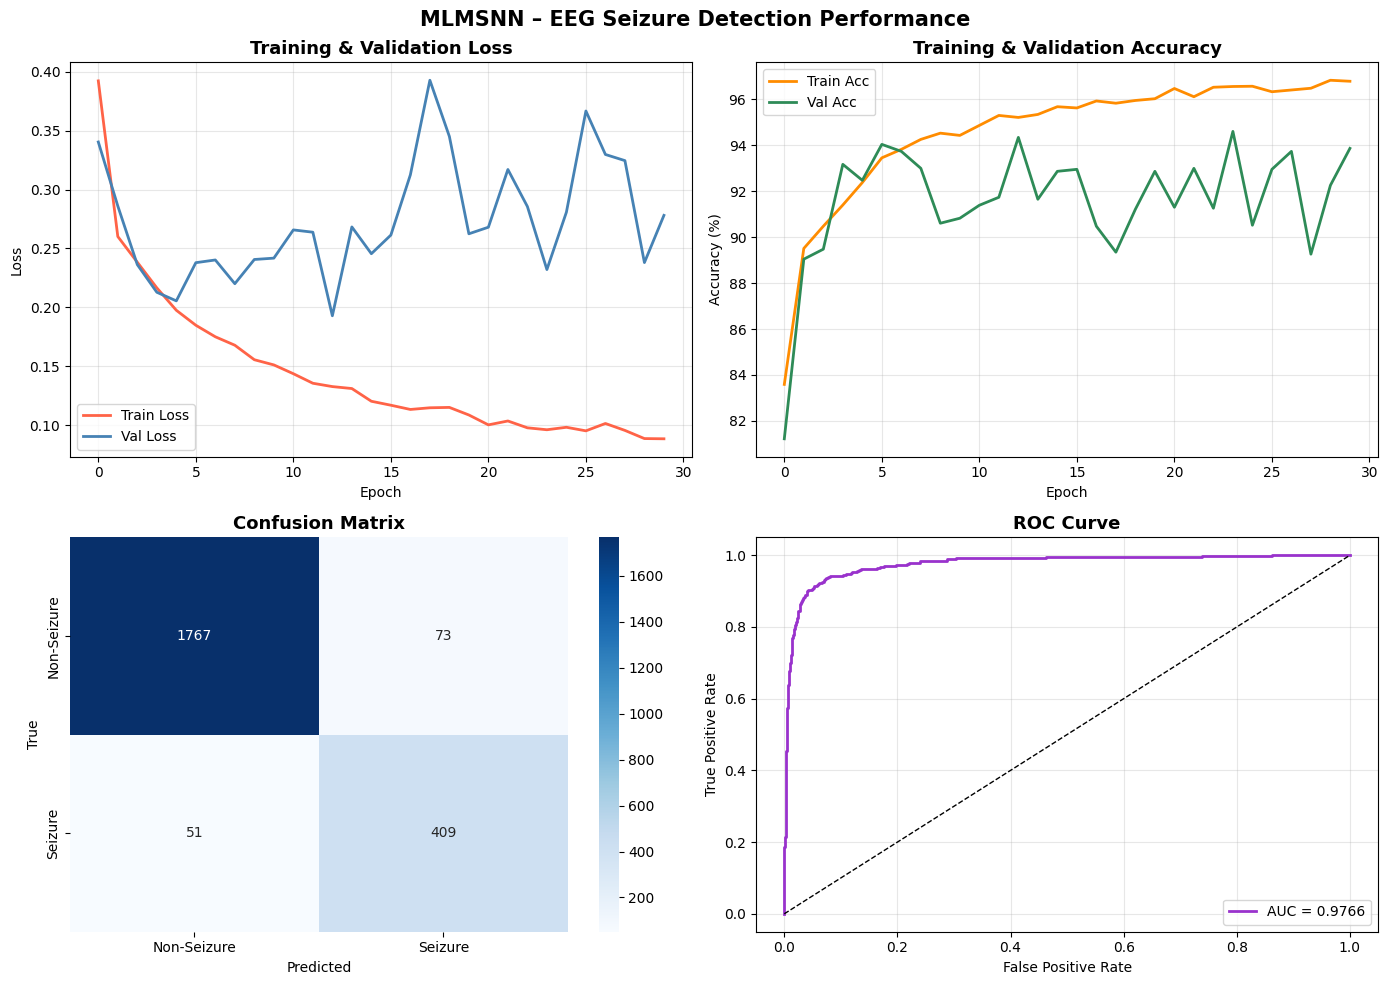

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curve
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='tomato',    linewidth=2)
ax.plot(history['val_loss'],   label='Val Loss',   color='steelblue', linewidth=2)
ax.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy curve
ax = axes[0, 1]
ax.plot([v*100 for v in history['train_acc']], label='Train Acc', color='darkorange', linewidth=2)
ax.plot([v*100 for v in history['val_acc']],   label='Val Acc',   color='seagreen',   linewidth=2)
ax.set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

# Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Seizure', 'Seizure'],
            yticklabels=['Non-Seizure', 'Seizure'])
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# ROC Curve
from sklearn.metrics import roc_curve
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='darkorchid', lw=2, label=f'AUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('MLMSNN – EEG Seizure Detection Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

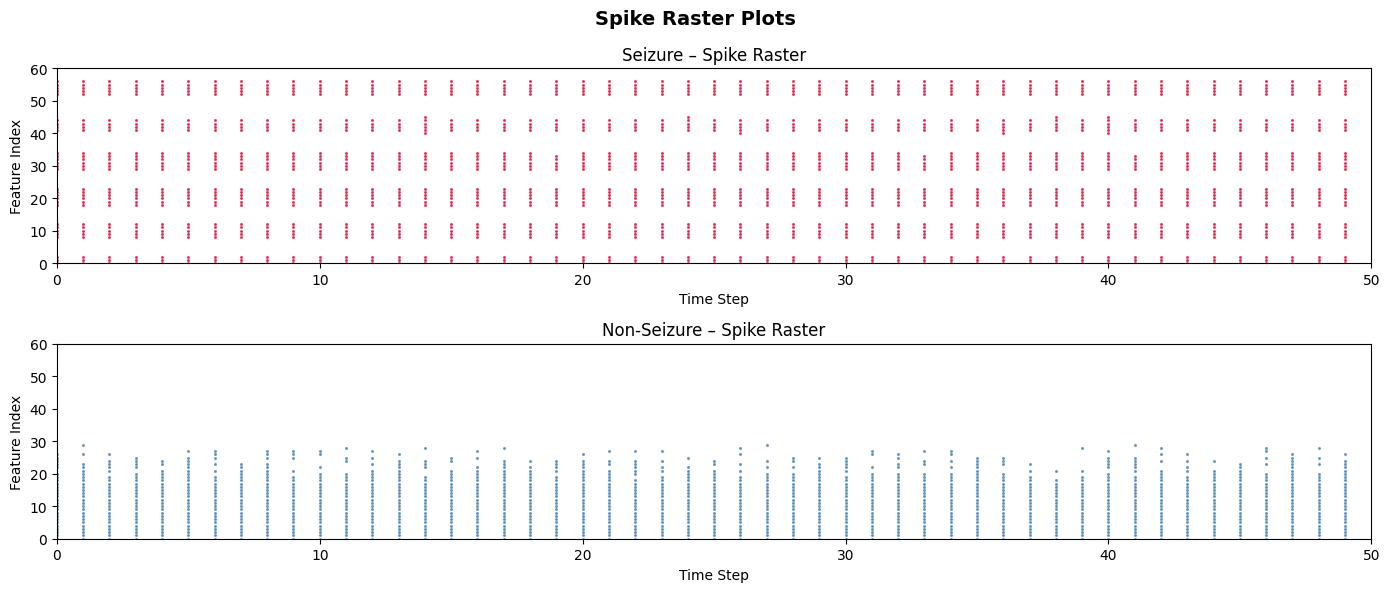

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for ax, class_val, label, color in zip(
    axes, [1, 0],
    ['Seizure – Spike Raster', 'Non-Seizure – Spike Raster'],
    ['crimson', 'steelblue']
):
    idx    = (y_test == class_val).nonzero()[0][0]
    spikes = X_test_spikes[:, idx, :60].numpy()
    times, feats = np.where(spikes)
    ax.scatter(times, feats, s=1.5, c=color, alpha=0.7)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Time Step'); ax.set_ylabel('Feature Index')
    ax.set_xlim(0, NUM_STEPS); ax.set_ylim(0, 60)

plt.suptitle('Spike Raster Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

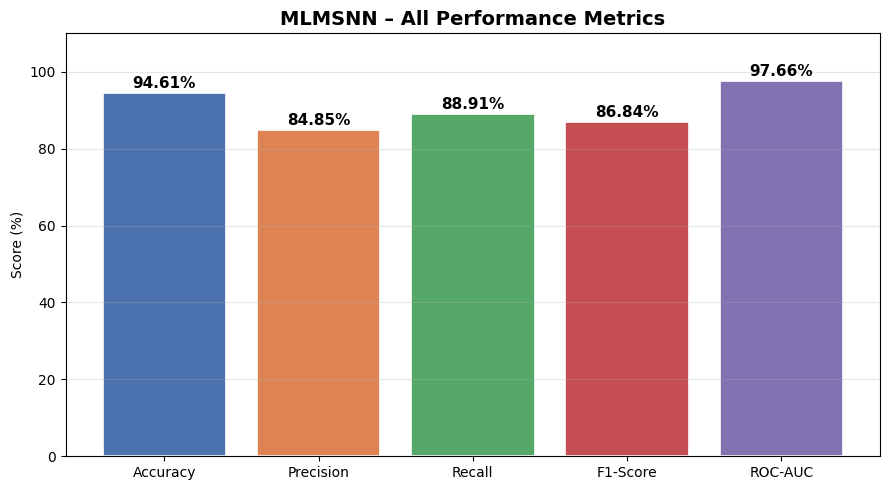

In [42]:
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics.keys(), [v * 100 for v in metrics.values()],
               color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, 110)
plt.title('MLMSNN – All Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
torch.save(model.state_dict(), 'SNN_EEG_final.pth')
print("Model saved: SNN_EEG_final.pth")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

Model saved: SNN_EEG_final.pth
Best validation accuracy: 94.61%


In [44]:
!streamlit run app.py &>/content/logs.txt &

In [45]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>